# Configs

In [60]:
S3_OUTPUT_PATH = "renate_experiments/benchmarking"
AWS_ACCOUNT_ID = "536276317016"
NUM_SEEDS = 3
UPDATERS = ["er", "finetuning", "joint"]
UPDATER_LABELS = {
    "er": "Experience Replay",
    #"gdumb": "GDumb",
    "finetuning": "Fine-Tuning",
    "joint": "Joint",
}
BENCHMARK_TYPE = "domain-incremental"
BENCHMARK = "iid-cifar10"

# Definitions

In [52]:
import json
from pathlib import Path
import tempfile
import shutil
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import boto3
  
from renate.benchmark.experimentation import execute_experiment_job, experiment_config_file
from renate.utils.file import maybe_download_from_s3


def submit_experiment(benchmark_type, benchmark, updater, num_seeds):
    benchmark_path = Path("benchmarking_configs") / benchmark_type / benchmark
    with open(benchmark_path / "scenario.json") as f:
        config_space = json.load(f)
    with open(benchmark_path / f"{updater}.json") as f:
        config_space.update(json.load(f))
    num_tasks = config_space["num_tasks"]
    del config_space["num_tasks"]
    for seed in range(num_seeds):
        execute_experiment_job(
            backend="sagemaker",
            config_file=experiment_config_file(),
            config_space=config_space,
            experiment_outputs_url=f"s3://sagemaker-us-west-2-{AWS_ACCOUNT_ID}/{S3_OUTPUT_PATH}/{benchmark_type}-{benchmark}-{updater}/{seed}",
            mode="max",
            metric="val_accuracy",
            num_updates=num_tasks,
            role=f"arn:aws:iam::{AWS_ACCOUNT_ID}:role/AmazonSageMakerServiceCatalogProductsUseRole",
            instance_type="ml.g4dn.xlarge",
            max_time=12 * 3600,
            n_workers=1,
            seed=seed,
            job_name=f"{benchmark}-{updater}-{seed}",
        )
        
def load_experiment_results(result_uri, num_tasks):
    assert num_tasks is not None
    bucket = f"sagemaker-us-west-2-{AWS_ACCOUNT_ID}"
    file_name = f"{result_uri}/logs/metrics_summary.csv"
    s3 = boto3.client("s3")
    obj = s3.get_object(Bucket=bucket, Key=file_name) 
    results = pd.read_csv(obj["Body"])
    file_name = f"{result_uri}/update_{num_tasks-1}/hpo.csv"
    obj = s3.get_object(Bucket=bucket, Key=file_name) 
    hpo = pd.read_csv(obj["Body"])
    results["time"] = np.cumsum(hpo.groupby(["update_id"])["st_tuner_time"].max())
    return results
    

def get_results(num_tasks):
    final_results = {}
    for updater in UPDATERS:
        results = []
        for seed in range(NUM_SEEDS):
            results.append(
                load_experiment_results(
                    f"{S3_OUTPUT_PATH}/{BENCHMARK_TYPE}-{BENCHMARK}-{updater}/{seed}",
                    num_tasks=num_tasks
                )
            )
        acc_results = [list(r["Average Accuracy"]) for r in results]
        time_results = [list(r["time"]) for r in results]
        final_results[updater] = {
            "mean": np.mean(acc_results, axis=0),
            "std": np.std(acc_results, axis=0),
            "min": np.min(acc_results, axis=0),
            "max": np.max(acc_results, axis=0),
            "mean_time": np.mean(time_results, axis=0),
        }
    return final_results

def get_num_tasks(benchmark_type, benchmark):
    benchmark_path = Path("benchmarking_configs") / benchmark_type / benchmark
    with open(benchmark_path / "scenario.json") as f:
        config_space = json.load(f)
    return config_space["num_tasks"]

def submit_rotation_experiment(benchmark_type, benchmark, updater, num_seeds, max_degree):
    benchmark_path = Path("benchmarking_configs") / benchmark_type / benchmark
    with open(benchmark_path / "scenario.json") as f:
        config_space = json.load(f)
    with open(benchmark_path / f"{updater}.json") as f:
        config_space.update(json.load(f))
    num_tasks = config_space["num_tasks"]
    del config_space["num_tasks"]
    assert benchmark_type == "domain-incremental"
    degrees_key = "data_module_fn_degrees"
    assert degrees_key in config_space
    config_space[degrees_key] = "[" + (",".join([str(int(d)) for d in np.arange(0, max_degree, max_degree / num_tasks)])) + "]"
    for seed in range(num_seeds):
        execute_experiment_job(
            backend="sagemaker",
            config_file=experiment_config_file(),
            config_space=config_space,
            experiment_outputs_url=f"s3://sagemaker-us-west-2-{AWS_ACCOUNT_ID}/{S3_OUTPUT_PATH}/{benchmark_type}-{benchmark}-{updater}-{max_degree}/{seed}",
            mode="max",
            metric="val_accuracy",
            num_updates=num_tasks,
            role=f"arn:aws:iam::{AWS_ACCOUNT_ID}:role/AmazonSageMakerServiceCatalogProductsUseRole",
            instance_type="ml.g4dn.xlarge",
            max_time=12 * 3600,
            n_workers=1,
            seed=seed,
            job_name=f"{benchmark}-{updater}-{seed}",
        )
        
def submit_sorting_experiment(benchmark_type, benchmark, updater, num_seeds, exponent):
    benchmark_path = Path("benchmarking_configs") / benchmark_type / benchmark
    with open(benchmark_path / "scenario.json") as f:
        config_space = json.load(f)
    with open(benchmark_path / f"{updater}.json") as f:
        config_space.update(json.load(f))
    num_tasks = config_space["num_tasks"]
    del config_space["num_tasks"]
    assert benchmark_type == "domain-incremental"
    exponent_key = "data_module_fn_exponent"
    assert exponent_key in config_space
    config_space[exponent_key] = str(exponent)
    for seed in range(num_seeds):
        execute_experiment_job(
            backend="sagemaker",
            config_file=experiment_config_file(),
            config_space=config_space,
            experiment_outputs_url=f"s3://sagemaker-us-west-2-{AWS_ACCOUNT_ID}/{S3_OUTPUT_PATH}/{benchmark_type}-{benchmark}-{updater}-{exponent}/{seed}",
            mode="max",
            metric="val_accuracy",
            num_updates=num_tasks,
            role=f"arn:aws:iam::{AWS_ACCOUNT_ID}:role/AmazonSageMakerServiceCatalogProductsUseRole",
            instance_type="ml.g4dn.xlarge",
            max_time=12 * 3600,
            n_workers=1,
            seed=seed,
            job_name=f"{benchmark}-{updater}-{seed}",
        )
        
def get_rotation_results(num_tasks, max_degree):
    final_results = {}
    for updater in UPDATERS:
        results = []
        for seed in range(NUM_SEEDS):
            results.append(
                load_experiment_results(
                    f"{S3_OUTPUT_PATH}/{BENCHMARK_TYPE}-{BENCHMARK}-{updater}-{max_degree}/{seed}",
                    num_tasks=num_tasks
                )
            )
        acc_results = [list(r["Average Accuracy"]) for r in results]
        time_results = [list(r["time"]) for r in results]
        final_results[updater] = {
            "mean": np.mean(acc_results, axis=0),
            "std": np.std(acc_results, axis=0),
            "min": np.min(acc_results, axis=0),
            "max": np.max(acc_results, axis=0),
            "mean_time": np.mean(time_results, axis=0),
        }
    return final_results

def plot(plot_results, xlabel, ylabel, title, output_file, ylim=None):
    plt.figure(facecolor="w")
    for label, results in plot_results.items():
        x = [str(int(x)) for x in np.arange(1, len(results["mean"]) + 1)]
        plt.plot(x, results["mean"], label=UPDATER_LABELS[label])
        plt.fill_between(x, results["mean"] - results["std"], results["mean"] + results["std"], alpha=0.3)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.legend()
    plt.savefig(output_file, bbox_inches="tight")
    
def plot_time(plot_results, xlabel, ylabel, title, output_file):
    plt.figure(facecolor="w")
    for label, results in plot_results.items():
        x = [str(int(x)) for x in np.arange(1, len(results["mean"]) + 1)]
        mean_time = [results["mean_time"][0]]
        for i in range(1, len(results["mean_time"])):
            mean_time.append(results["mean_time"][i] - results["mean_time"][i-1])
        plt.plot(x, mean_time, label=UPDATER_LABELS[label])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.savefig(output_file, bbox_inches="tight")

# Submit Jobs

In [13]:
assert BENCHMARK == "sorting-cifar10"
for updater in UPDATERS:
    for exponent in [1, 10, 100, 1000]:
        submit_sorting_experiment(BENCHMARK_TYPE, BENCHMARK, updater, NUM_SEEDS, exponent)

In [7]:
assert BENCHMARK == "rotation-mnist"
for updater in UPDATERS:
    for max_degree in [5, 10, 15, 20, 45, 60, 75, 90, 120, 150]:
        submit_rotation_experiment(BENCHMARK_TYPE, BENCHMARK, updater, NUM_SEEDS, max_degree)

In [5]:
assert BENCHMARK not in ["sorting-cifar10", "rotation-mnist"]
for updater in UPDATERS:
    submit_experiment(BENCHMARK_TYPE, BENCHMARK, updater, NUM_SEEDS)

# Results

In [39]:
assert BENCHMARK == "rotation-mnist"
final_results = {}
for max_degree in [5, 20, 45, 60, 90, 120, 150]:
    final_results[max_degree] = get_rotation_results(num_tasks=get_num_tasks(BENCHMARK_TYPE, BENCHMARK), max_degree=max_degree)

In [59]:
final_results = get_results(num_tasks=get_num_tasks("class-incremental", "cifar10-resnet18"))

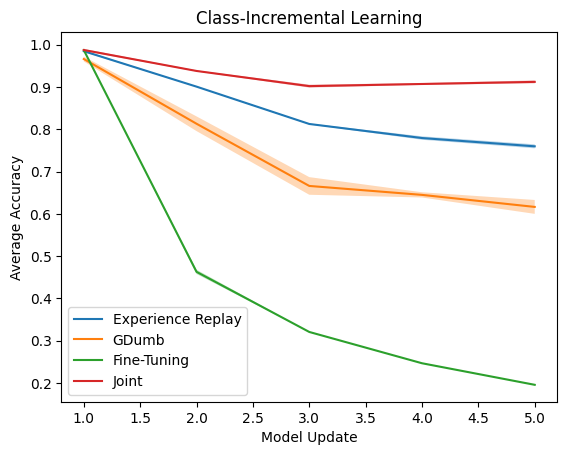

In [4]:
plt.figure(facecolor="w")
for label, results in final_results.items():
    x = np.arange(1, len(results["mean"]) + 1)
    plt.plot(x, results["mean"], label=UPDATER_LABELS[label])
    plt.fill_between(x, results["mean"] - results["std"], results["mean"] + results["std"], alpha=0.3)
plt.xlabel("Model Update")
plt.ylabel("Average Accuracy")
plt.title("Class-Incremental Learning")
plt.legend()

# Rotation MNIST

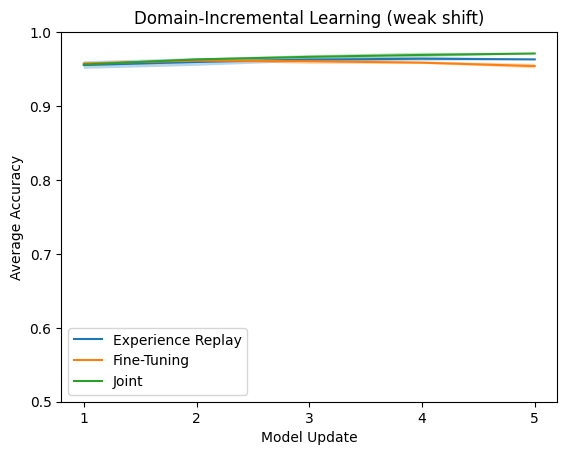

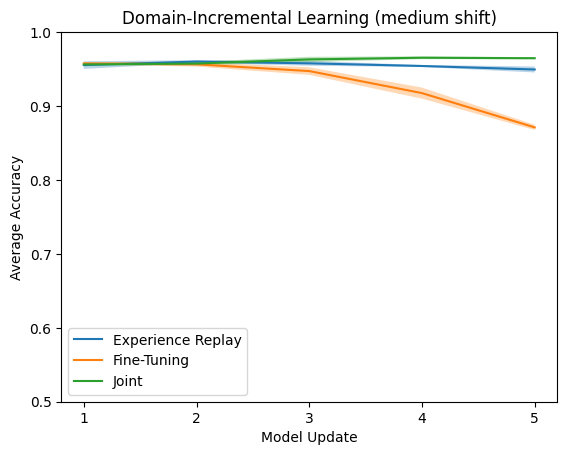

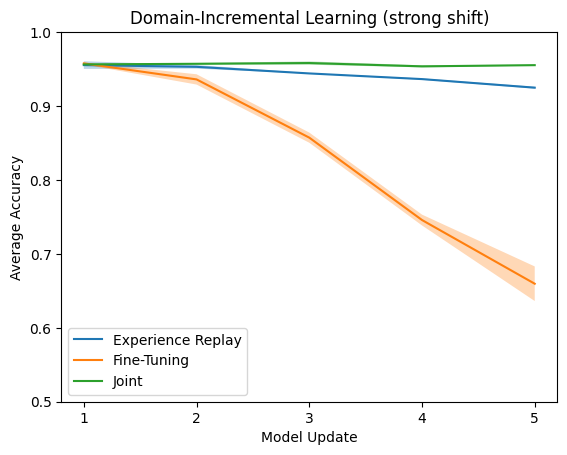

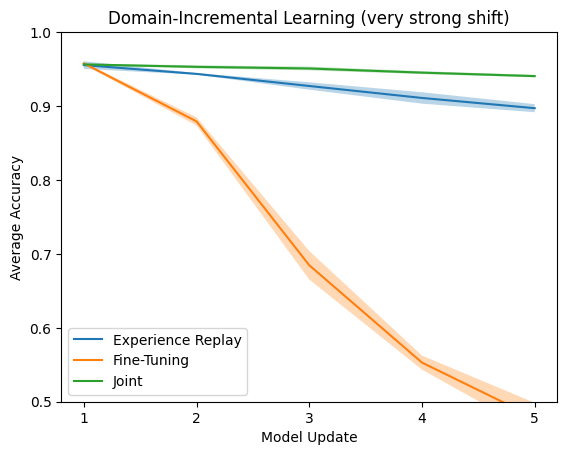

In [47]:
for max_degree, noise in zip([20, 45, 90, 150], ["weak", "medium", "strong", "very strong"]):
    plot(
        final_results[max_degree],
        xlabel="Model Update",
        ylabel="Average Accuracy",
        title=f"Domain-Incremental Learning ({noise} shift)",
        output_file=f"figs/rotation_mnist_{noise}_avg_acc.pdf",
        ylim=(0.5, 1)
    )

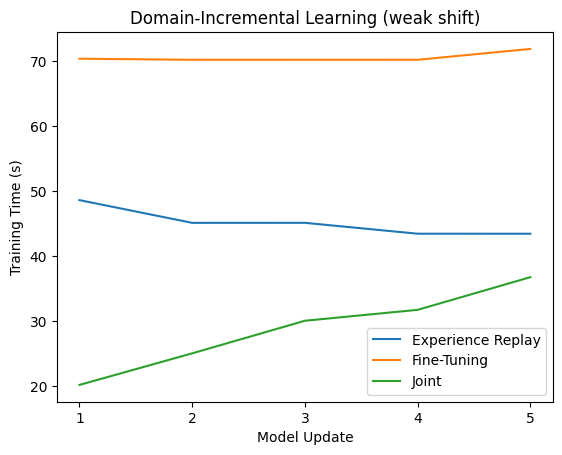

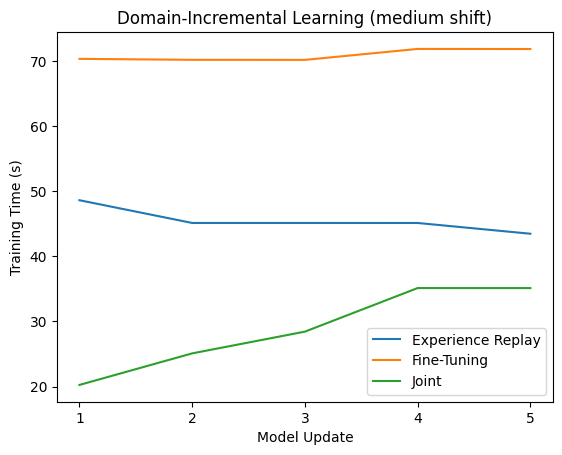

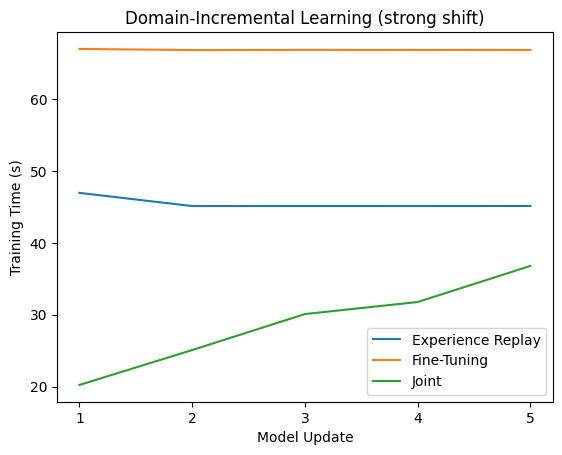

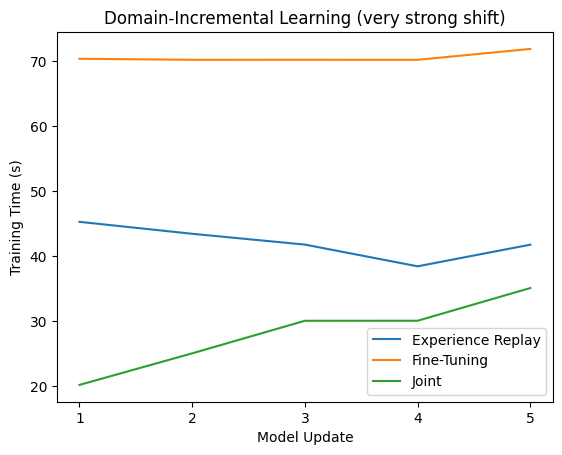

In [49]:
for max_degree, noise in zip([20, 45, 90, 150], ["weak", "medium", "strong", "very strong"]):
    plot_time(
        final_results[max_degree],
        xlabel="Model Update",
        ylabel="Training Time (s)",
        title=f"Domain-Incremental Learning ({noise} shift)",
        output_file=f"figs/rotation_mnist_{noise}_time.pdf",
    )

# IID

In [61]:
final_results = get_results(num_tasks=get_num_tasks("domain-incremental", "iid-cifar10"))

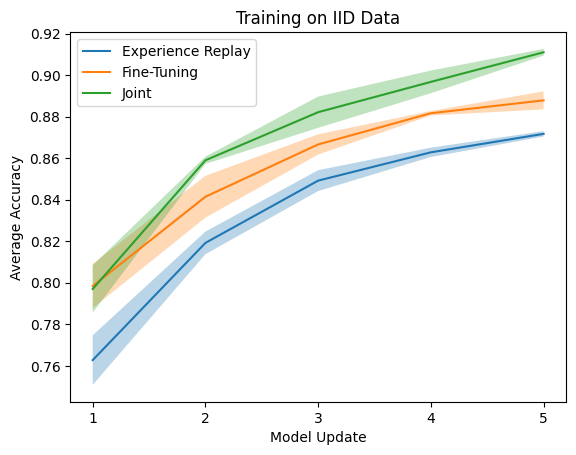

In [62]:
plot(
    final_results,
    xlabel="Model Update",
    ylabel="Average Accuracy",
    title="Training on IID Data",
    output_file="figs/iid_avg_acc.pdf",
)

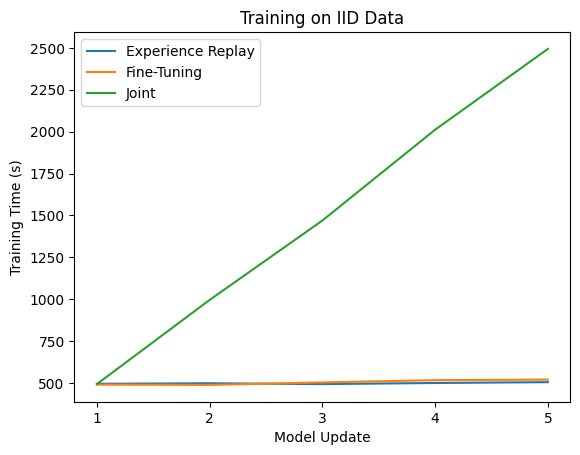

In [63]:
plot_time(
    final_results,
    xlabel="Model Update",
    ylabel="Training Time (s)",
    title="Training on IID Data",
    output_file="figs/iid_time.pdf",
)